In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")  # so `src` is importable from Notebooks/

import torch
import pandas as pd
from pathlib import Path
from torch.utils.data import DataLoader

from src.dataloader import SkinDataset
from src.transforms import val_transform
from src.models import build_model
from src.evaluate import evaluate

CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROJECT_ROOT = Path.cwd().parent  # adjust if Evaluate.ipynb isn't directly under Notebooks/

In [2]:
test_df = pd.read_csv(PROJECT_ROOT / "test_split.csv")

test_dataset = SkinDataset(
    dataframe=test_df,
    image_folder=str(PROJECT_ROOT / "HAM10000_images"),
    transform=val_transform
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Test set size: {len(test_df)}")
print(test_df["dx"].value_counts())  # sanity check class distribution

Test set size: 1503
dx
nv       1006
mel       167
bkl       165
bcc        77
akiec      49
vasc       22
df         17
Name: count, dtype: int64


In [3]:
def load_checkpoint(model_name, checkpoint_path):
    model = build_model(model_name=model_name, num_classes=7).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.eval()
    return model

In [7]:
effnet_model = load_checkpoint("efficientnet", PROJECT_ROOT / "best_model_efficientnet.pth")
effnet_results = evaluate(effnet_model, test_loader, DEVICE, CLASS_NAMES)

KeyboardInterrupt: 

Accuracy    : 0.6860
Macro F1    : 0.5630
Weighted F1 : 0.7152

Classification Report

              precision    recall  f1-score   support

       akiec       0.37      0.78      0.50        49
         bcc       0.50      0.84      0.63        77
         bkl       0.59      0.44      0.50       165
          df       0.21      0.41      0.28        17
         mel       0.34      0.69      0.45       167
          nv       0.96      0.71      0.82      1006
        vasc       0.68      0.86      0.76        22

    accuracy                           0.69      1503
   macro avg       0.52      0.68      0.56      1503
weighted avg       0.80      0.69      0.72      1503



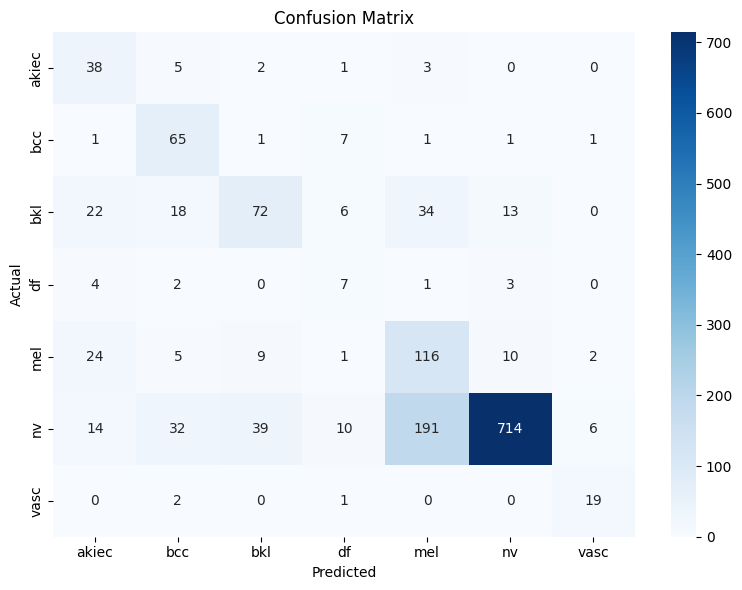


Per Class Accuracy

akiec     : 0.7755
bcc       : 0.8442
bkl       : 0.4364
df        : 0.4118
mel       : 0.6946
nv        : 0.7097
vasc      : 0.8636


In [6]:
resnet_model = load_checkpoint("resnet", PROJECT_ROOT / "best_model_resnet.pth")
resnet_results = evaluate(resnet_model, test_loader, DEVICE, CLASS_NAMES)

In [18]:
import matplotlib.pyplot as plt
from src.predict import predict_image

# pick a real test image from your held-out set
sample_row = test_df.iloc[10]
sample_path = PROJECT_ROOT / "HAM10000_images" / f"{sample_row['image_id']}.jpg"
true_label = sample_row["dx"]

print(f"True label: {true_label}")


True label: bcc


Prediction : bcc
Confidence : 0.9696


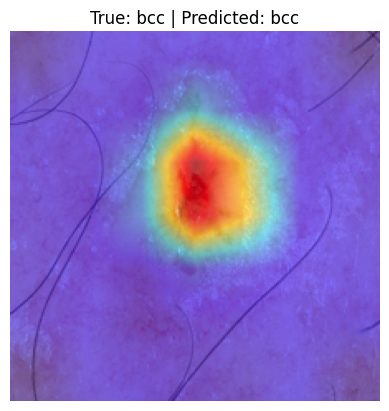

In [19]:
result = predict_image(effnet_model, str(sample_path), DEVICE, model_name="efficientnet")

print(f"Prediction : {result['prediction']}")
print(f"Confidence : {result['confidence']:.4f}")

plt.imshow(result["heatmap"])
plt.title(f"True: {true_label} | Predicted: {result['prediction']}")
plt.axis("off")
plt.show()